In [5]:
import pandas as pd 
import matplotlib.pyplot as plt

In [95]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn import preprocessing 
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
import numpy as np

In [85]:
url= "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML0101EN-SkillsNetwork/labs/Module%202/data/FuelConsumptionCo2.csv"

In [8]:
df = pd.read_csv(url)

In [48]:
city = df['FUELCONSUMPTION_CITY']
hwy= df['FUELCONSUMPTION_HWY']
comb = df['FUELCONSUMPTION_COMB']
comb_mpg = df['FUELCONSUMPTION_COMB_MPG']

engine_size = df['ENGINESIZE']
co2_emmision = df['CO2EMISSIONS']
cylinder = df['CYLINDERS']

fuel_type = df['FUELTYPE']

Text(0, 0.5, 'co2 emmision')

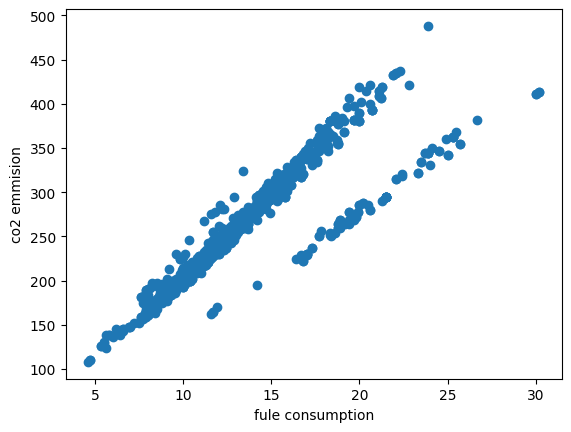

In [35]:
plt.scatter(city , co2_emmision)
plt.xlabel('fule consumption')
plt.ylabel('co2 emmision')

In [74]:
enc = preprocessing.OneHotEncoder()
enc.fit(df[['FUELTYPE']])
enc.categories_

[array(['D', 'E', 'X', 'Z'], dtype=object)]

In [75]:
one_hot = enc.transform(df[['FUELTYPE']]).toarray()
df[['D', 'E', 'X', 'Z']] = one_hot

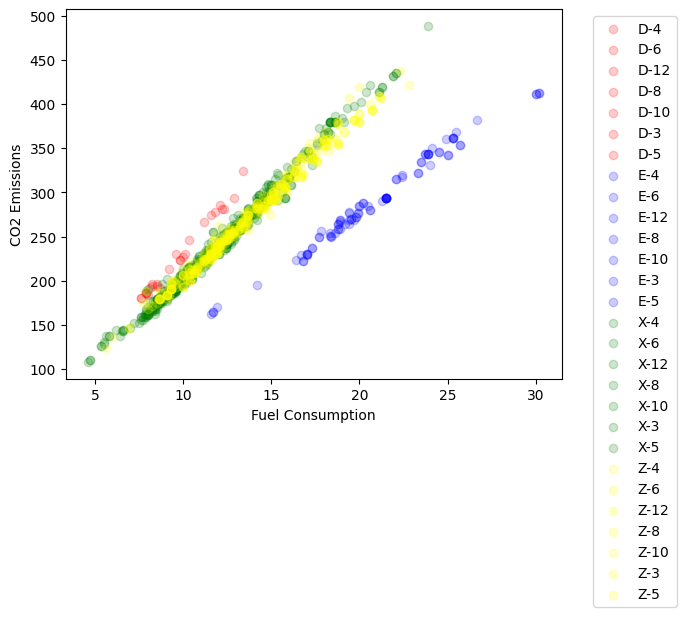

In [77]:
types = { 'red' : 'D', 'blue':'E', 'green': 'X','yellow':'Z'}
cyln = [4, 6, 12, 8, 10, 3, 5]

for col, fuel_type in types.items():
    for i in cyln:
        subset = df[(df['CYLINDERS'] == i) & (df['FUELTYPE'] == fuel_type)]
        plt.scatter(
            subset['FUELCONSUMPTION_CITY'],
            subset['CO2EMISSIONS'],
            color=col,
            alpha=0.2,
            label=f"{fuel_type}-{i}"
        )

plt.xlabel('Fuel Consumption')
plt.ylabel('CO2 Emissions')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

In [89]:
X = df[['FUELCONSUMPTION_CITY']]
y = df['CO2EMISSIONS']

In [91]:
X_train, X_test, y_train, y_test = train_test_split(
    X , y,
    test_size = 0.2,
    random_state = 42
)

In [92]:
model = LinearRegression()
model.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [93]:
y_pred = model.predict(X_test)

In [96]:
print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

MAE: 19.437233522675424
R2 Score: 0.8184231533160797
